<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/visualization/visualize_advanced_sampler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Multilevel Subset Simulation ===
N per level                 : 4000
p0                          : 0.1
n_seeds                     : 400
chain length                : 10
proposal sigma              : 0.8

Level 1:  P(F1)               ≈ 0.100000   threshold b1=1.5447   tau=1.000   CoV≈0.047
Level 2:  P(F2|F1)       ≈ 0.100250   threshold b2=2.6590   tau=5.405   CoV≈0.110
Level 3:  P(F3|F2)       ≈ 0.101000   threshold b3=3.5857   tau=6.833   CoV≈0.123
Level 4:  P(F4|F3)       ≈ 0.101250   threshold b4=4.4499   tau=7.301   CoV≈0.127
Level 5:  P(Failure|F4)   ≈ 0.839000   threshold beta=4.5000  tau=10.616   CoV≈0.023

Estimated P_F               : 8.601273e-05
Approx. CoV(P_F)            : 0.217
Approx. std(P_F)            : 1.865650e-05
Reference P_F               : 7.579151e-05
Relative error              : 13.49%
Mean MCMC acceptance rate   : 0.266


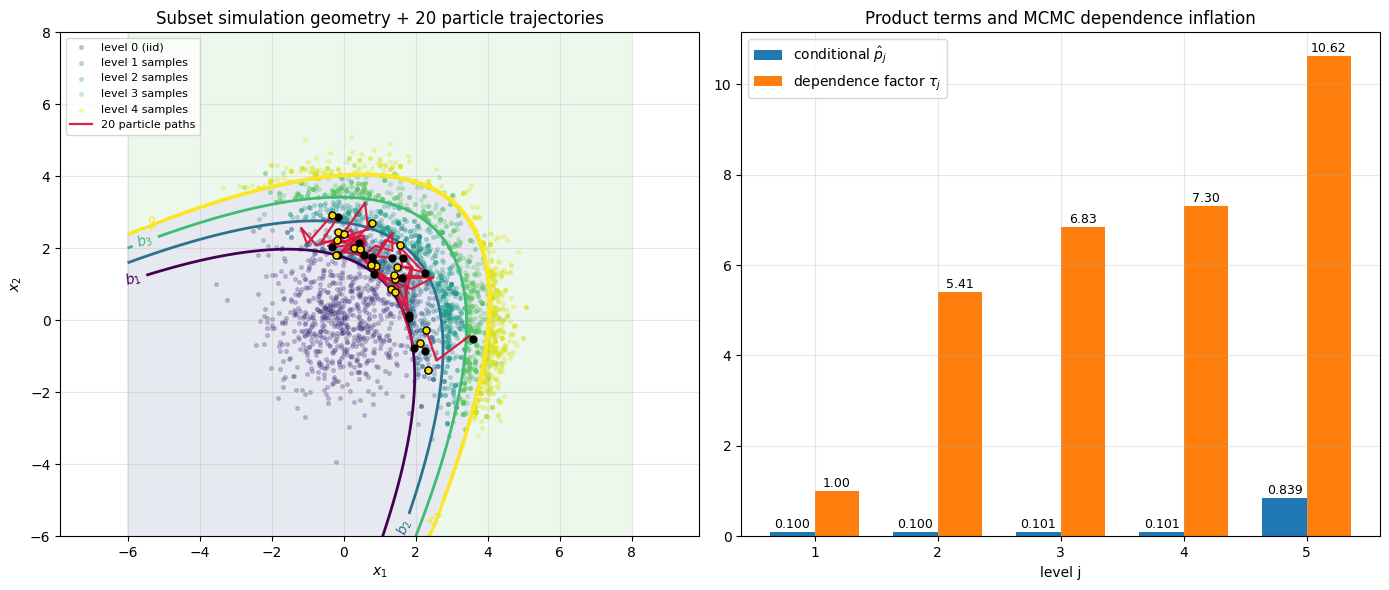

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad

# ============================================================
# Toy rare-event problem
# ============================================================
beta = 4.5
c = 0.1

def h(X):
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    return (x1 + x2) / np.sqrt(2) + c * (x1 - x2) ** 2

def reference_pf(beta=beta, c=c):
    integrand = lambda z: norm.pdf(z) * (1 - norm.cdf(beta - 2 * c * z**2))
    val, _ = quad(integrand, -np.inf, np.inf, limit=200)
    return val

pf_ref = reference_pf()

# ============================================================
# Parameters
# ============================================================
N = 4000
p0 = 0.10
proposal_sigma = 0.8
seed = 123

# visualization of particle paths
n_paths_to_plot = 20
path_level_to_plot = 1   # 1 = chains generated after reaching F1, 2 = after F2, etc.

rng = np.random.default_rng(seed)

n_seeds = int(N * p0)
assert N % n_seeds == 0
chain_len = N // n_seeds

# ============================================================
# MCMC kernel
# ============================================================
def generate_conditional_samples(seeds, threshold, chain_len, proposal_sigma, rng):
    n_chains, d = seeds.shape
    chains = np.empty((n_chains, chain_len, d))
    scores = np.empty((n_chains, chain_len))
    accept_count = 0
    proposal_count = 0

    for i, x0 in enumerate(seeds):
        x = x0.copy()
        chains[i, 0] = x
        scores[i, 0] = h(x)[0]

        for t in range(1, chain_len):
            x_prop = x + proposal_sigma * rng.standard_normal(d)
            proposal_count += 1

            if h(x_prop)[0] >= threshold:
                log_alpha = -0.5 * (x_prop @ x_prop - x @ x)
                if np.log(rng.random()) < min(0.0, log_alpha):
                    x = x_prop
                    accept_count += 1

            chains[i, t] = x
            scores[i, t] = h(x)[0]

    acc_rate = accept_count / max(proposal_count, 1)
    return chains, scores, acc_rate

# ============================================================
# Integrated autocorrelation factor for binary chains
# ============================================================
def pooled_iat_binary(binary_chains, max_lag=None):
    Y = np.asarray(binary_chains, dtype=float)
    n_chains, L = Y.shape
    p = Y.mean()
    var = p * (1.0 - p)

    if var <= 1e-14 or L < 2:
        return 1.0

    if max_lag is None:
        max_lag = min(L - 1, 20)

    tau = 1.0
    for lag in range(1, max_lag + 1):
        a = Y[:, :-lag]
        b = Y[:, lag:]
        rho = np.mean((a - p) * (b - p)) / var
        if rho <= 0:
            break
        tau += 2.0 * rho

    return max(tau, 1.0)

# ============================================================
# Multilevel subset simulation
# ============================================================
level_samples = []
level_scores = []
level_thresholds = []
level_cond_probs = []
level_tau = []
level_cov_cond = []
level_accept_rates = []
level_chains = []   # stores actual MCMC trajectories

X = rng.standard_normal((N, 2))
S = h(X)

level_samples.append(X.copy())
level_scores.append(S.copy())

pf_hat = 1.0
current_level = 0

while True:
    q = np.quantile(S, 1 - p0)
    b_next = beta if q >= beta else q

    I_next = (S >= b_next).astype(float)
    p_hat_j = I_next.mean()

    if current_level == 0:
        tau_j = 1.0
    else:
        I_chains = I_next.reshape(n_seeds, chain_len)
        tau_j = pooled_iat_binary(I_chains)

    cov2_j = tau_j * (1.0 - p_hat_j) / (N * p_hat_j)
    cov_j = np.sqrt(cov2_j)

    level_thresholds.append(b_next)
    level_cond_probs.append(p_hat_j)
    level_tau.append(tau_j)
    level_cov_cond.append(cov_j)

    pf_hat *= p_hat_j

    if b_next >= beta:
        break

    idx = np.argsort(S)[-n_seeds:]
    seeds = X[idx]

    chains, score_chains, acc_rate = generate_conditional_samples(
        seeds=seeds,
        threshold=b_next,
        chain_len=chain_len,
        proposal_sigma=proposal_sigma,
        rng=rng,
    )

    level_chains.append(chains.copy())

    X = chains.reshape(-1, 2)
    S = score_chains.reshape(-1)

    level_samples.append(X.copy())
    level_scores.append(S.copy())
    level_accept_rates.append(acc_rate)

    current_level += 1

cov2_total = np.prod([1 + c**2 for c in level_cov_cond]) - 1
cov_total = np.sqrt(cov2_total)

# ============================================================
# Print summary
# ============================================================
print("=== Multilevel Subset Simulation ===")
print(f"N per level                 : {N}")
print(f"p0                          : {p0}")
print(f"n_seeds                     : {n_seeds}")
print(f"chain length                : {chain_len}")
print(f"proposal sigma              : {proposal_sigma}")
print()

for j, (b, pj, tauj, covj) in enumerate(zip(level_thresholds, level_cond_probs, level_tau, level_cov_cond), start=1):
    if j == 1:
        print(f"Level {j}:  P(F1)               ≈ {pj:.6f}   threshold b1={b:.4f}   tau={tauj:.3f}   CoV≈{covj:.3f}")
    elif j < len(level_thresholds):
        print(f"Level {j}:  P(F{j}|F{j-1})       ≈ {pj:.6f}   threshold b{j}={b:.4f}   tau={tauj:.3f}   CoV≈{covj:.3f}")
    else:
        print(f"Level {j}:  P(Failure|F{j-1})   ≈ {pj:.6f}   threshold beta={b:.4f}  tau={tauj:.3f}   CoV≈{covj:.3f}")

print()
print(f"Estimated P_F               : {pf_hat:.6e}")
print(f"Approx. CoV(P_F)            : {cov_total:.3f}")
print(f"Approx. std(P_F)            : {pf_hat * cov_total:.6e}")
print(f"Reference P_F               : {pf_ref:.6e}")
print(f"Relative error              : {(pf_hat - pf_ref)/pf_ref:.2%}")

if level_accept_rates:
    print(f"Mean MCMC acceptance rate   : {np.mean(level_accept_rates):.3f}")

# ============================================================
# Visualization
# ============================================================
xx = np.linspace(-6, 8, 500)
yy = np.linspace(-6, 8, 500)
X1, X2 = np.meshgrid(xx, yy)
H = (X1 + X2) / np.sqrt(2) + c * (X1 - X2) ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------------------------------------
# Left: geometry + 20 particle trajectories
# ------------------------------------------------------------
ax = axes[0]
ax.contourf(X1, X2, H >= beta, levels=[-0.5, 0.5, 1.5], alpha=0.12)

contour_levels = level_thresholds.copy()
cs = ax.contour(X1, X2, H, levels=contour_levels, linewidths=2)

fmt = {}
for j, b in enumerate(level_thresholds, start=1):
    fmt[b] = fr"$b_{j}$" if b < beta else r"$\beta$"
ax.clabel(cs, fmt=fmt, inline=True, fontsize=10)

colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(level_samples)))
for j, (Xj, col) in enumerate(zip(level_samples, colors)):
    idx = np.random.default_rng(100 + j).choice(len(Xj), size=min(700, len(Xj)), replace=False)
    label = "level 0 (iid)" if j == 0 else f"level {j} samples"
    ax.scatter(Xj[idx, 0], Xj[idx, 1], s=7, alpha=0.25, color=col, label=label)

# ---- add 20 lines for 20 particles ----
if len(level_chains) >= path_level_to_plot:
    chains_to_show = level_chains[path_level_to_plot - 1]
    n_show = min(n_paths_to_plot, chains_to_show.shape[0])

    # evenly spaced chain indices for nicer coverage
    chosen = np.linspace(0, chains_to_show.shape[0] - 1, n_show, dtype=int)

    for k, idx_chain in enumerate(chosen):
        path = chains_to_show[idx_chain]
        ax.plot(
            path[:, 0], path[:, 1],
            lw=1.6, alpha=0.95, color="crimson",
            label="20 particle paths" if k == 0 else None
        )
        ax.scatter(path[0, 0], path[0, 1], s=24, color="black", zorder=5)
        ax.scatter(path[-1, 0], path[-1, 1], s=26, color="gold", edgecolor="black", zorder=6)

ax.set_title(f"Subset simulation geometry + {n_paths_to_plot} particle trajectories")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xlim(-6, 8)
ax.set_ylim(-6, 8)
ax.axis("equal")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper left")

# ------------------------------------------------------------
# Right: conditional probs and dependence inflation
# ------------------------------------------------------------
ax = axes[1]
levels = np.arange(1, len(level_cond_probs) + 1)

ax.bar(levels - 0.18, level_cond_probs, width=0.36, label=r"conditional $\hat p_j$")
ax.bar(levels + 0.18, level_tau, width=0.36, label=r"dependence factor $\tau_j$")

for x, p in zip(levels - 0.18, level_cond_probs):
    ax.text(x, p + 0.02, f"{p:.3f}", ha="center", va="bottom", fontsize=9)

for x, t in zip(levels + 0.18, level_tau):
    ax.text(x, t + 0.02, f"{t:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(levels)
ax.set_xticklabels([f"{j}" for j in levels])
ax.set_xlabel("level j")
ax.set_title("Product terms and MCMC dependence inflation")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

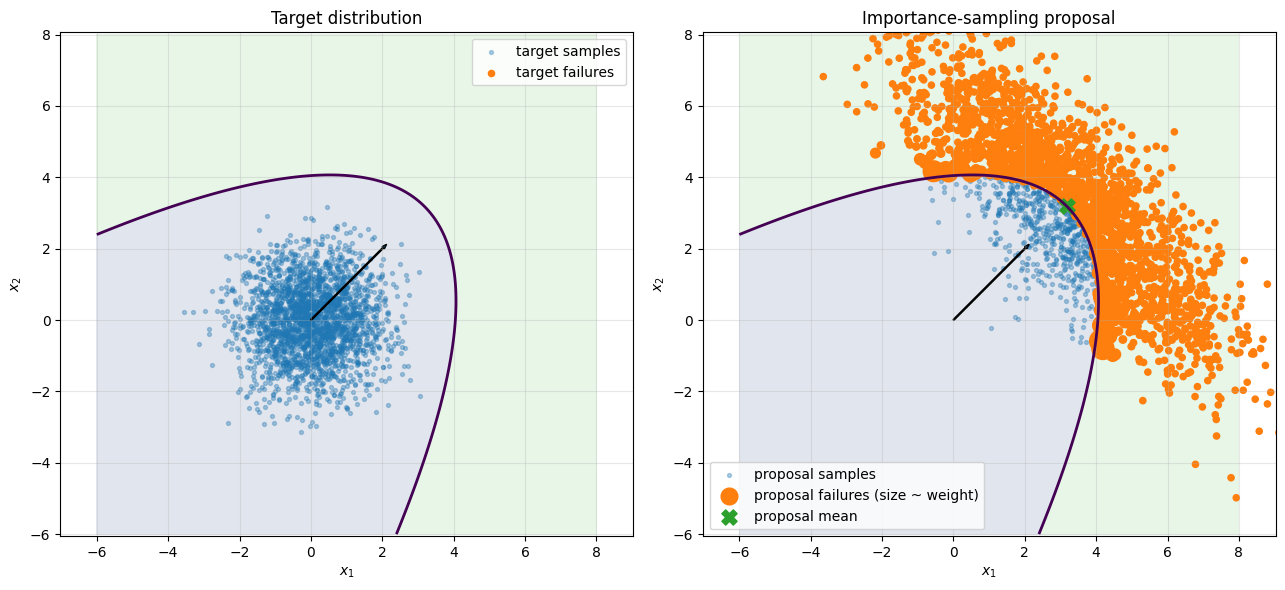

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Problem definition
# ============================================================
beta = 4.5
c = 0.1

def score(x):
    x = np.atleast_2d(x)
    return (x[:, 0] + x[:, 1]) / np.sqrt(2) + c * (x[:, 0] - x[:, 1])**2

alpha = np.array([1.0, 1.0]) / np.sqrt(2)     # important direction
v = np.array([1.0, -1.0]) / np.sqrt(2)        # orthogonal direction

seed = 123
rng = np.random.default_rng(seed)

# IS proposal in rotated coordinates
mu_t = beta
sigma_z = 3.0

N_target = 2500
N_prop = 2500

# Target samples
X_target = rng.standard_normal((N_target, 2))
fail_target = score(X_target) >= beta

# Proposal samples
t = rng.normal(loc=mu_t, scale=1.0, size=N_prop)
z = rng.normal(loc=0.0, scale=sigma_z, size=N_prop)
X_prop = np.outer(t, alpha) + np.outer(z, v)
fail_prop = score(X_prop) >= beta

# Importance weights p/q
logw_t = -mu_t * t + 0.5 * mu_t**2
logw_z = np.log(sigma_z) - 0.5 * z**2 + 0.5 * (z / sigma_z)**2
w = np.exp(logw_t + logw_z)

# ============================================================
# Background geometry
# ============================================================
xx = np.linspace(-6, 8, 400)
yy = np.linspace(-6, 8, 400)
X1, X2 = np.meshgrid(xx, yy)
H = (X1 + X2) / np.sqrt(2) + c * (X1 - X2)**2

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# -------- Left: target distribution
ax = axes[0]
ax.contourf(X1, X2, H >= beta, levels=[-0.5, 0.5, 1.5], alpha=0.15)
ax.contour(X1, X2, H, levels=[beta], linewidths=2)
ax.scatter(X_target[:, 0], X_target[:, 1], s=8, alpha=0.35, label='target samples')
ax.scatter(X_target[fail_target, 0], X_target[fail_target, 1], s=20, label='target failures')
ax.arrow(0, 0, 3*alpha[0], 3*alpha[1], width=0.03, length_includes_head=True)
ax.set_title("Target distribution")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.axis("equal")
ax.set_xlim(-6, 8)
ax.set_ylim(-6, 8)
ax.grid(alpha=0.3)
ax.legend()

# -------- Right: proposal distribution
ax = axes[1]
ax.contourf(X1, X2, H >= beta, levels=[-0.5, 0.5, 1.5], alpha=0.15)
ax.contour(X1, X2, H, levels=[beta], linewidths=2)
ax.scatter(X_prop[:, 0], X_prop[:, 1], s=8, alpha=0.35, label='proposal samples')

if fail_prop.any():
    sizes = 20 + 250 * (w[fail_prop] / w[fail_prop].max())
    ax.scatter(X_prop[fail_prop, 0], X_prop[fail_prop, 1], s=sizes, label='proposal failures (size ~ weight)')

proposal_mean = mu_t * alpha
ax.scatter([proposal_mean[0]], [proposal_mean[1]], s=120, marker='X', label='proposal mean')
ax.arrow(0, 0, 3*alpha[0], 3*alpha[1], width=0.03, length_includes_head=True)
ax.set_title("Importance-sampling proposal")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.axis("equal")
ax.set_xlim(-6, 8)
ax.set_ylim(-6, 8)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

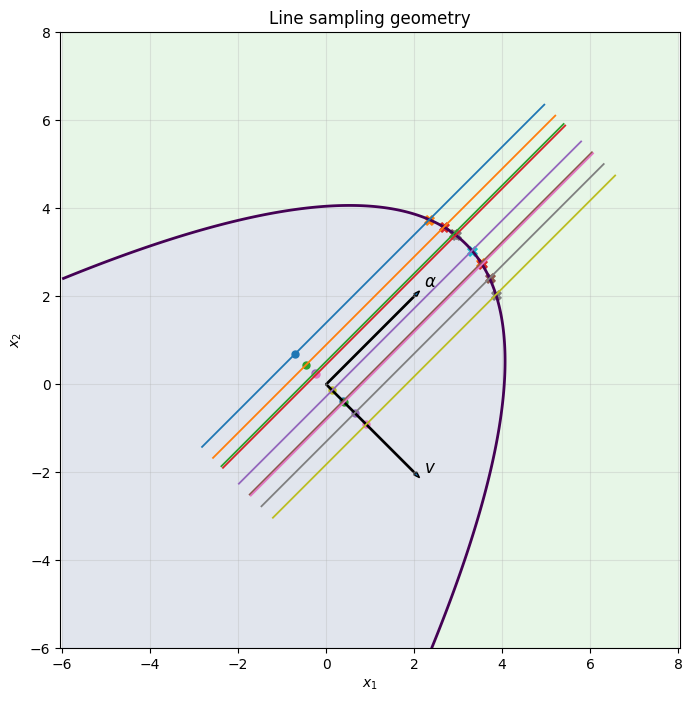

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Problem definition
# ============================================================
beta = 4.5
c = 0.1

alpha = np.array([1.0, 1.0]) / np.sqrt(2)     # important direction
v = np.array([1.0, -1.0]) / np.sqrt(2)        # orthogonal direction

seed = 123
rng = np.random.default_rng(seed)

# In rotated coordinates:
# x = t * alpha + z * v
# failure when t + 2 c z^2 >= beta
z_vals = np.sort(rng.normal(0, 1, 9))
t_grid = np.linspace(-3, 8, 400)

# ============================================================
# Background geometry
# ============================================================
xx = np.linspace(-6, 8, 400)
yy = np.linspace(-6, 8, 400)
X1, X2 = np.meshgrid(xx, yy)
H = (X1 + X2) / np.sqrt(2) + c * (X1 - X2)**2

plt.figure(figsize=(8, 8))
plt.contourf(X1, X2, H >= beta, levels=[-0.5, 0.5, 1.5], alpha=0.15)
plt.contour(X1, X2, H, levels=[beta], linewidths=2)

for z in z_vals:
    # line: x(t) = t alpha + z v
    X_line = np.outer(t_grid, alpha) + np.outer(np.full_like(t_grid, z), v)
    plt.plot(X_line[:, 0], X_line[:, 1], lw=1.3)

    # point where the line hits the failure boundary
    t_star = beta - 2 * c * z**2
    x_star = t_star * alpha + z * v
    x_base = z * v

    plt.scatter([x_base[0]], [x_base[1]], s=25)   # base point on perpendicular direction
    plt.scatter([x_star[0]], [x_star[1]], s=45, marker='X')  # entry point into failure

# Important and orthogonal directions
plt.arrow(0, 0, 3*alpha[0], 3*alpha[1], width=0.03, length_includes_head=True)
plt.arrow(0, 0, 3*v[0], 3*v[1], width=0.03, length_includes_head=True)

plt.text(3*alpha[0] + 0.1, 3*alpha[1] + 0.1, r"$\alpha$", fontsize=12)
plt.text(3*v[0] + 0.1, 3*v[1] + 0.1, r"$v$", fontsize=12)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Line sampling geometry")
plt.axis("equal")
plt.xlim(-6, 8)
plt.ylim(-6, 8)
plt.grid(alpha=0.3)
plt.show()